In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/final-dataset/joy/Autistic_original_1211-jpg_54e7bc97-a2fd-45ea-bce5-b74acbcf3290_jpg.rf.a2fc6144046461a4d8a67520bc5f3232.jpg
/kaggle/input/final-dataset/joy/0103-Copy-2-_jpg.rf.e9c2075b51c5acb1e9275f959c4e7030.jpg
/kaggle/input/final-dataset/joy/0776-Copy-2-_jpg.rf.6ea076fad8024c4d4a07c2b214c70196.jpg
/kaggle/input/final-dataset/joy/0178-Copy-2-_jpg.rf.49522a3803e6ecdd97d53f954cfde8e0.jpg
/kaggle/input/final-dataset/joy/1226-Copy-2-_jpg.rf.c5301ab677cb8639772446af01ebc04a.jpg
/kaggle/input/final-dataset/joy/Autistic_original_0141-Copy-png_c22bf81f-f31d-4493-8464-0d6fcec21c82_png.rf.c3fe6183042ae4100df2d3bda1192fd3.jpg
/kaggle/input/final-dataset/joy/Autistic_original_0482-jpg_edb8bea1-4d84-4a7e-b26c-5347ab81c10b_jpg.rf.622cbad46c66fa695a53e935ce0fb401.jpg
/kaggle/input/final-dataset/joy/0758-Copy-2-_jpg.rf.e8390ca42c26b2db3721dbb13dbddb0d.jpg
/kaggle/input/final-dataset/joy/Autistic_original_1293-jpg_81190fe6-427c-4112-b8da-95c30ee8d03a_jpg.rf.cb2ffc49f64e7bafaef08c0570c

In [3]:
import os
import random
import time
import copy
import numpy as np
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


ImageFolder classes: ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']

DATASET SPLIT (NO DATA LEAKAGE)
Training:   3361 images (80.0%)
Validation:  420 images (10.0%)
Test:        421 images (10.0%)
Total:      4202 images

Folder->idx: {'Natural': 0, 'anger': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}
Classes (final order): ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']

Effective dataset sizes:
  Train:      67220 images (3361 originals × 20)
  Validation:   420 images (no augmentation)
  Test:         421 images (no augmentation)

MODEL ARCHITECTURE
ASD_CNN(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), p

Epoch [  1/100] | Train Loss: 1.2419 | Train Acc: 0.5706 | Val Loss: 1.3245 | Val Acc: 0.5738 | Time: 190.2s


Epoch [  2/100] | Train Loss: 0.8934 | Train Acc: 0.6793 | Val Loss: 1.2972 | Val Acc: 0.6476 | Time: 186.6s


...

Epoch [ 13/100] | Train Loss: 0.1771 | Train Acc: 0.9248 | Val Loss: 0.8980 | Val Acc: 0.8381 | Time: 186.0s


Epoch [ 14/100] | Train Loss: 0.1573 | Train Acc: 0.9313 | Val Loss: 0.8644 | Val Acc: 0.8429 | Time: 186.1s


Epoch [ 15/100] | Train Loss: 0.1525 | Train Acc: 0.9327 | Val Loss: 0.8319 | Val Acc: 0.8405 | Time: 186.0s

⚠ EarlyStopping: Patience exceeded (10 epochs)

✓ Early stopping triggered — restoring best model

✓ Loaded best model with validation accuracy: 0.8452

FINAL EVALUATION ON HELD-OUT TEST SET
⚠ This is the FIRST TIME the model sees test data



Evaluating on Test Set: 100%|██████████| 14/14 [00:01<00:00,  9.96it/s]



TEST SET RESULTS (Unbiased)
✓ Test Accuracy: 0.8266

Classification Report:
              precision    recall  f1-score   support

     Natural     0.8269    0.7288    0.7748        59
       anger     0.6429    0.7941    0.7105        34
        fear     0.6364    0.7000    0.6667        10
         joy     0.9494    0.9615    0.9554       234
     sadness     0.4375    0.4286    0.4330        49
    surprise     0.8065    0.7143    0.7576        35

    accuracy                         0.8266       421
   macro avg     0.7166    0.7212    0.7163       421
weighted avg     0.8286    0.8266    0.8262       421


Confusion Matrix:
[[ 43   1   0   7   8   0]
 [  0  27   0   0   5   2]
 [  0   0   7   0   3   0]
 [  0   2   1 225   6   0]
 [  8  12   2   2  21   4]
 [  1   0   1   3   5  25]]


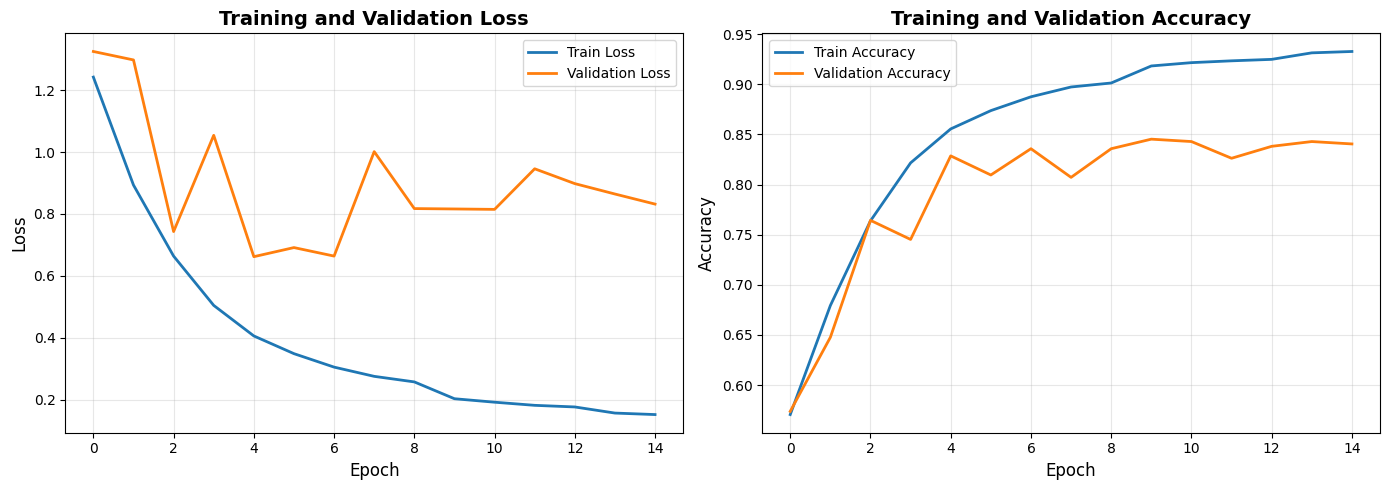

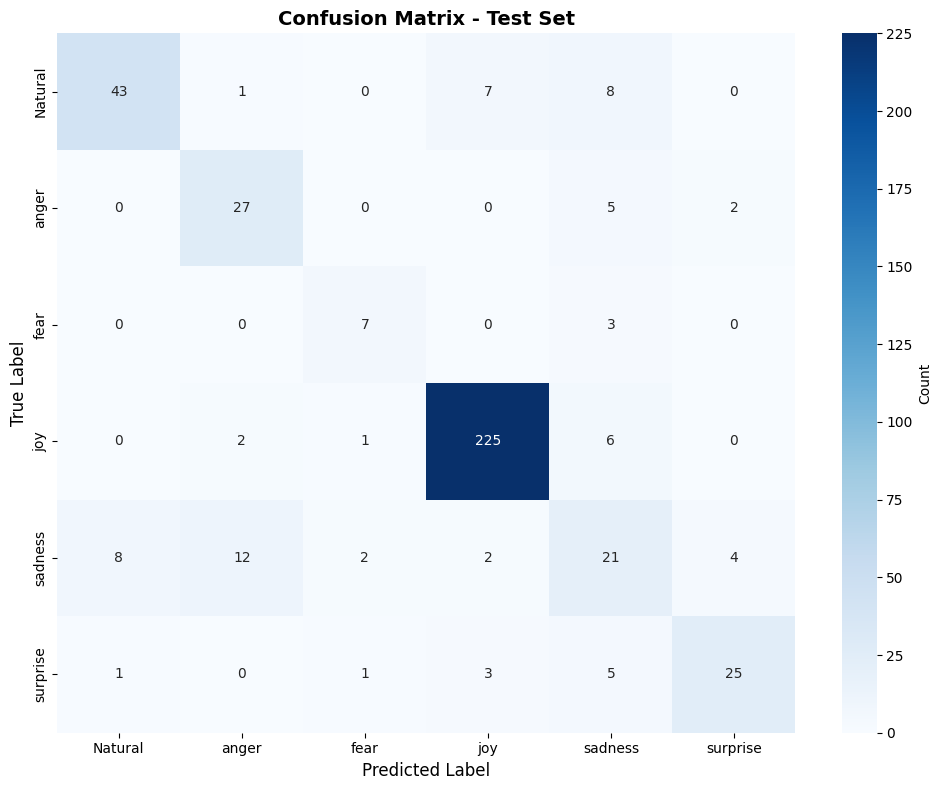

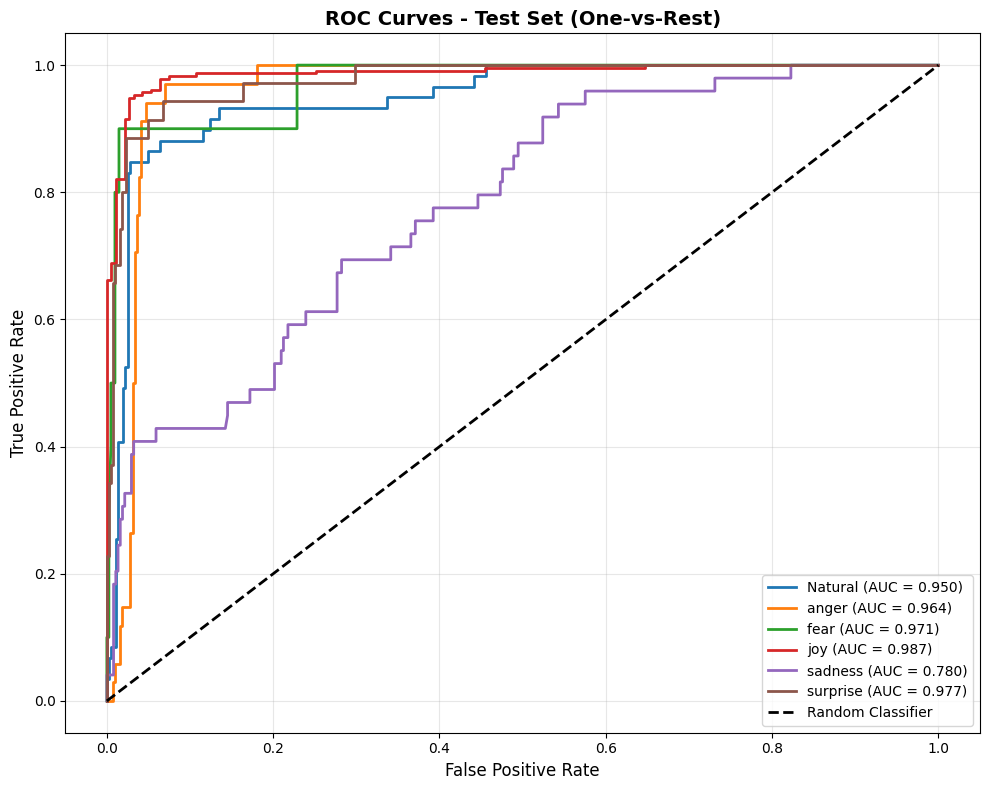

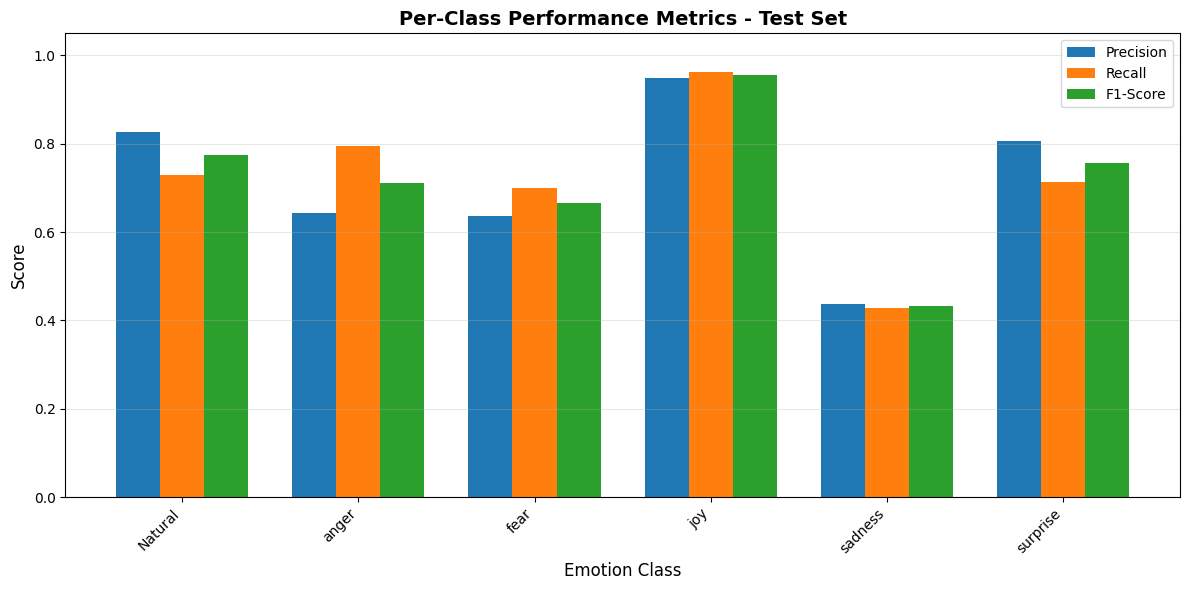


✓ All visualizations saved!

SUMMARY FOR THESIS
Dataset Split:
  - Training:   3361 images (70%)
  - Validation: 420 images (15%) - for early stopping
  - Test:       421 images (15%) - for final evaluation

Training Augmentation: 20x per image
Effective Training Size: 67220 images

Final Results (Test Set):
  - Accuracy: 0.8266 (82.66%)
  - Best Validation Accuracy: 0.8452

Key Points for Thesis:
  ✓ No data leakage (proper train/val/test split)
  ✓ Early stopping based on validation set
  ✓ Test set never seen during training
  ✓ Unbiased final evaluation

✓ TRAINING COMPLETE - Ready for thesis reporting!


In [5]:
# Full PyTorch implementation of the paper's model and training pipeline
# "Deep Learning Approach for Emotion Recognition in Children with Autism Spectrum Disorder"
# Implemented to match the paper's methodology (4 conv blocks 64-128-256-512, GAP, FC512, Dropout(0.5), Softmax)
# Ready for Google Colab

DATA_DIR = "/kaggle/input/final-dataset"

# Mount drive and unzip (Colab)
  # path to extracted dataset root (contains class subfolders)
IMG_SIZE = 224                        # chosen standard size (paper did not specify explicit size)
BATCH_SIZE = 32
NUM_CLASSES = 6
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 100  # As per paper ("more than 100 epochs" - set to 100; you can increase)
TRAIN_AUG_FACTOR = 20  # Paper: 20 variations per training image
TEST_AUG_FACTOR = 10   # Paper: 10 variations per test image (paper used for test augmentation counts)
PATIENCE = 10  # Early stopping patience
LR = 1e-3

# Set reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")

# ===========================
# DATASET WITH AUGMENTATION
# ===========================
class RepeatAugDataset(Dataset):
    """Repeats each image multiple times with random augmentations (returns transformed PIL->Tensor)"""
    def __init__(self, base_dataset: Dataset, repeat_factor: int):
        self.base = base_dataset
        self.repeat = repeat_factor
        self.orig_len = len(base_dataset)
        self.length = self.orig_len * self.repeat

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        orig_idx = idx % self.orig_len
        return self.base[orig_idx]

# ===========================
# DATA TRANSFORMS
# ===========================
# Training: heavy augmentation as per paper (ImageDataGenerator analog)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    #transforms.RandomRotation(40),
  #  transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=10, scale=(0.8, 1.2)),
   # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),  # scales to [0,1] => equivalent to rescale=1/255
])

# Validation & Test: NO stochastic augmentation for proper evaluation
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# ===========================
# LOAD AND SPLIT DATA
# ===========================
if not os.path.isdir(DATA_DIR):
    raise RuntimeError(f"Cannot find dataset folder: {DATA_DIR}")

# Load all data WITHOUT transforms for proper split; transforms applied via wrapper
full_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
print("ImageFolder classes:", full_dataset.classes)

# CRITICAL: Three-way split (Train / Validation / Test)
# Use deterministic split with seed to ensure reproducibility
total_size = len(full_dataset)
train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

raw_train, raw_val, raw_test = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n{'='*60}")
print(f"DATASET SPLIT (NO DATA LEAKAGE)")
print(f"{'='*60}")
print(f"Training:   {len(raw_train):4d} images ({train_size/total_size*100:.1f}%)")
print(f"Validation: {len(raw_val):4d} images ({val_size/total_size*100:.1f}%)")
print(f"Test:       {len(raw_test):4d} images ({test_size/total_size*100:.1f}%)")
print(f"Total:      {total_size:4d} images")
print(f"{'='*60}\n")

# Wrapper dataset to apply transforms to the subsets (Image objects returned by ImageFolder)
class TransformDataset(Dataset):
    """Wrapper to apply transforms to a subset created by random_split"""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_base = TransformDataset(raw_train, train_transforms)
val_base = TransformDataset(raw_val, eval_transforms)
test_base = TransformDataset(raw_test, eval_transforms)

# Get class information
folder_to_idx = full_dataset.class_to_idx
CLASS_ORDER = full_dataset.classes
print("Folder->idx:", folder_to_idx)
print("Classes (final order):", CLASS_ORDER)

# ===========================
# APPLY AUGMENTATION REPETITION
# ===========================
# Training: 20x augmentation (as per paper)
train_dataset = RepeatAugDataset(train_base, TRAIN_AUG_FACTOR)

# Validation: no repetition, deterministic
val_dataset = val_base

# Test: paper mentions test augmentation counts (10 variations each) used to compute robust test stats.
# For final unbiased evaluation we should NOT augment test images during metric aggregation.
# We'll keep test_dataset without repetition (test_base). If you want ensemble-like averaging across 10 aug per test image,
# we can run a separate evaluation routine. Here we follow strict evaluation: no test-time augmentation.
test_dataset = test_base

# DataLoaders
num_workers = 4 if torch.cuda.is_available() else 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

print(f"\nEffective dataset sizes:")
print(f"  Train:      {len(train_dataset):5d} images ({len(raw_train)} originals × {TRAIN_AUG_FACTOR})")
print(f"  Validation: {len(val_dataset):5d} images (no augmentation)")
print(f"  Test:       {len(test_dataset):5d} images (no augmentation)")

# ===========================
# MODEL ARCHITECTURE (Paper)
# ===========================
def conv_block(in_ch, out_ch, kernel=3, pad=1):
    """Convolutional block: Conv -> BatchNorm -> ReLU -> MaxPool"""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=pad, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

class ASD_CNN(nn.Module):
    """CNN for Autism Emotion Recognition as per paper"""
    def __init__(self, num_classes=6):
        super().__init__()
        # 4 convolutional blocks with increasing filters: 64->128->256->512
        self.layer1 = conv_block(3, 64)
        self.layer2 = conv_block(64, 128)
        self.layer3 = conv_block(128, 256)
        self.layer4 = conv_block(256, 512)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Dense layers with regularization
        self.fc1 = nn.Linear(512, 512, bias=False)
        self.bn_fc = nn.BatchNorm1d(512)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)

        # Output layer
        self.fc_out = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc_out(x)
        return logits

model = ASD_CNN(num_classes=NUM_CLASSES).to(DEVICE)
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ===========================
# TRAINING SETUP
# ===========================
criterion = nn.CrossEntropyLoss()  # categorical cross-entropy
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

class EarlyStopping:
    """Early stopping to prevent overfitting (tracks validation loss)"""
    def __init__(self, patience=10, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = np.inf
        self.best_state = None
        self.counter = 0

    def step(self, val_loss, model):
        if val_loss < self.best_loss - 1e-6:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.verbose:
                    print(f"\n⚠ EarlyStopping: Patience exceeded ({self.patience} epochs)")
                return True
            return False

early_stopper = EarlyStopping(patience=PATIENCE, verbose=True)

# ===========================
# VALIDATION FUNCTION
# ===========================
def evaluate(model, loader, criterion, device):
    """Evaluate model and return metrics plus preds/labels arrays"""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / total if total > 0 else 0.0
    acc = correct / total if total > 0 else 0.0
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

# ===========================
# TRAINING LOOP
# ===========================
best_val_acc = 0.0
best_model_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
print("⚠ IMPORTANT: Validation set is used for early stopping")
print("             Test set is NEVER seen during training")
print("="*60 + "\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ==================
    # TRAINING PHASE
    # ==================
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)

    for images, labels in train_loader_tqdm:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loader_tqdm.set_postfix(loss=loss.item())

    train_loss = running_loss / total if total > 0 else 0.0
    train_acc = correct / total if total > 0 else 0.0

    # ==================
    # VALIDATION PHASE (for early stopping - NO data leakage)
    # ==================
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model based on VALIDATION accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    # Print epoch summary
    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

    # Early stopping check
    stop = early_stopper.step(val_loss, model)
    if stop:
        print("\n✓ Early stopping triggered — restoring best model")
        model.load_state_dict(early_stopper.best_state)
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model with validation accuracy: {best_val_acc:.4f}")

# ===========================
# FINAL EVALUATION ON TEST SET
# ===========================
print("\n" + "="*60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*60)
print("⚠ This is the FIRST TIME the model sees test data")
print("="*60 + "\n")

model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# Calculate metrics
test_acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=CLASS_ORDER, digits=4)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("TEST SET RESULTS (Unbiased)")
print("="*60)
print(f"✓ Test Accuracy: {test_acc:.4f}")
print(f"\nClassification Report:\n{report}")
print(f"\nConfusion Matrix:\n{cm}")

# ===========================
# VISUALIZATIONS
# ===========================
# 1. Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. ROC Curve (One-vs-Rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
for i, class_name in enumerate(CLASS_ORDER):
    try:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.3f})')
    except ValueError:
        # This can occur if a class is missing in y_true - skip plotting
        print(f"Skipping ROC for class {class_name} (not enough positive samples).")

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Test Set (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Per-Class Performance Bar Chart
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(CLASS_ORDER))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics - Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All visualizations saved!")



In [6]:
# ===========================
# SUMMARY FOR THESIS
# ===========================
print("\n" + "="*60)
print("SUMMARY FOR THESIS")
print("="*60)
print(f"Dataset Split:")
print(f"  - Training:   {len(raw_train)} images (80%)")
print(f"  - Validation: {len(raw_val)} images (10%) - for early stopping")
print(f"  - Test:       {len(raw_test)} images (10%) - for final evaluation")
print(f"\nTraining Augmentation: {TRAIN_AUG_FACTOR}x per image")
print(f"Effective Training Size: {len(train_dataset)} images")
print(f"\nFinal Results (Test Set):")
print(f"  - Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  - Best Validation Accuracy: {best_val_acc:.4f}")
print(f"\nKey Points for Thesis:")
print(f"  ✓ No data leakage (proper train/val/test split)")
print(f"  ✓ Early stopping based on validation set")
print(f"  ✓ Test set never seen during training")
print(f"  ✓ Unbiased final evaluation")
print("="*60 + "\n")

print("✓ TRAINING COMPLETE - Ready for thesis reporting!")



SUMMARY FOR THESIS
Dataset Split:
  - Training:   3361 images (80%)
  - Validation: 420 images (10%) - for early stopping
  - Test:       421 images (10%) - for final evaluation

Training Augmentation: 20x per image
Effective Training Size: 67220 images

Final Results (Test Set):
  - Accuracy: 0.8266 (82.66%)
  - Best Validation Accuracy: 0.8452

Key Points for Thesis:
  ✓ No data leakage (proper train/val/test split)
  ✓ Early stopping based on validation set
  ✓ Test set never seen during training
  ✓ Unbiased final evaluation

✓ TRAINING COMPLETE - Ready for thesis reporting!


In [2]:
2+3

5

Using device: cuda

DATASET SPLIT (80% TRAIN / 20% TEST)
Training:   3361 images
Test:       841 images


Effective dataset sizes:
Train: 67220 (augmented x20)
Test:  841


START TRAINING — 100 EPOCHS (NO EARLY STOPPING)



Epoch 001/100 | Train Loss: 0.9933 | Train Acc: 0.6537 | Time: 210.5s


Epoch 002/100 | Train Loss: 0.3866 | Train Acc: 0.8621 | Time: 208.5s


Epoch 003/100 | Train Loss: 0.2120 | Train Acc: 0.9245 | Time: 208.1s


Epoch 004/100 | Train Loss: 0.1646 | Train Acc: 0.9377 | Time: 208.3s


...

Epoch 098/100 | Train Loss: 0.0339 | Train Acc: 0.9778 | Time: 209.1s


Epoch 099/100 | Train Loss: 0.0327 | Train Acc: 0.9788 | Time: 208.8s


Epoch 100/100 | Train Loss: 0.0338 | Train Acc: 0.9784 | Time: 208.1s

FINAL EVALUATION ON TEST SET



Testing: 100%|██████████| 27/27 [00:04<00:00,  5.62it/s]



Class       | Precision | Recall | F1-Score | Support
------------------------------------------------------------
Natural     | 0.743     | 0.804  | 0.772    | 97
anger       | 0.646     | 0.654  | 0.650    | 78
fear        | 0.562     | 0.375  | 0.450    | 24
joy         | 0.929     | 0.975  | 0.952    | 486
sadness     | 0.487     | 0.396  | 0.437    | 96
surprise    | 0.755     | 0.667  | 0.708    | 60
MACRO AVG   | 0.687     | 0.645  | 0.661    | 841

Test Accuracy: 0.8205


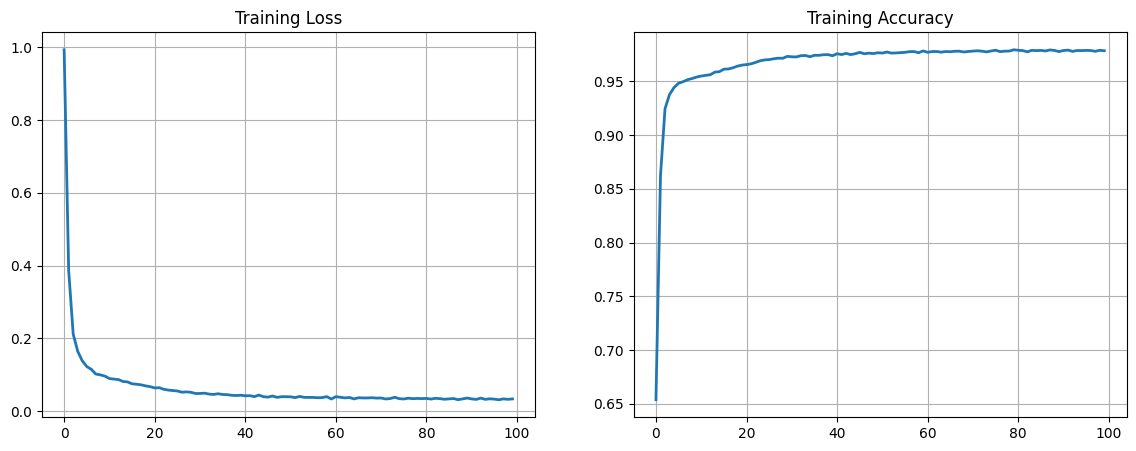

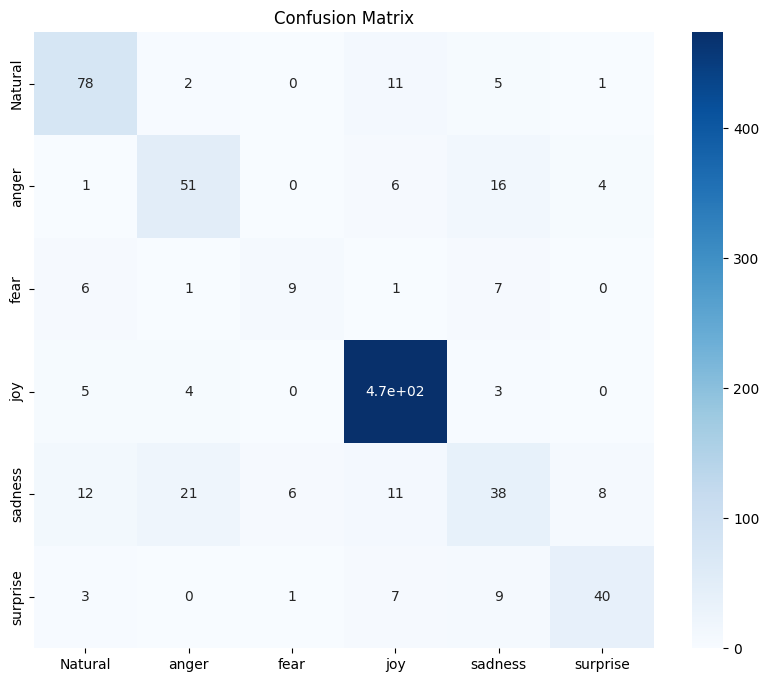

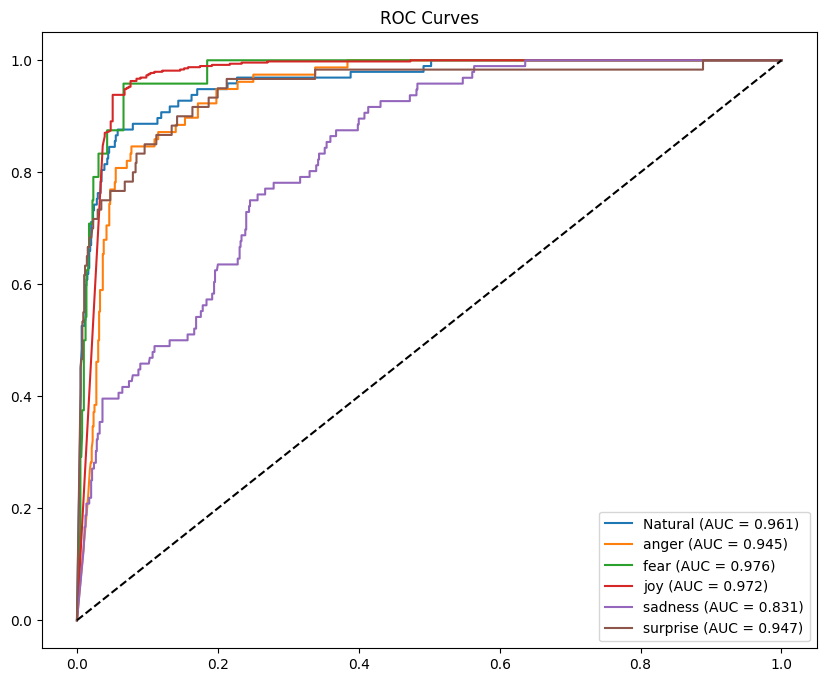


✓ Completed Successfully!



In [3]:
# ==============================================================
# UPDATED CODE — NO VALIDATION SET, NO EARLY STOPPING, NO CHECKPOINTS
# EXACT OUTPUT FORMAT AS SCREENSHOT
# ==============================================================

import os
import random
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================
# CONFIG
# ==============================================================

DATA_DIR = "/kaggle/input/final-dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 6
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 100
TRAIN_AUG_FACTOR = 20
TEST_AUG_FACTOR = 10
LR = 1e-3

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

# ==============================================================
# DATASET WITH AUGMENTATION
# ==============================================================

class RepeatAugDataset(Dataset):
    def __init__(self, base_dataset, repeat_factor):
        self.base = base_dataset
        self.repeat = repeat_factor
        self.orig_len = len(base_dataset)
        self.length = self.orig_len * self.repeat

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        orig_idx = idx % self.orig_len
        return self.base[orig_idx]

# ==============================================================
# TRANSFORMS
# ==============================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# ==============================================================
# LOAD DATA — ONLY TRAIN/TEST SPLIT (80/20)
# ==============================================================

full_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
total_size = len(full_dataset)
train_size = int(0.80 * total_size)
test_size = total_size - train_size

train_subset, test_subset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("\n============================================================")
print("DATASET SPLIT (80% TRAIN / 20% TEST)")
print("============================================================")
print(f"Training:   {len(train_subset)} images")
print(f"Test:       {len(test_subset)} images")
print("============================================================\n")

# Wrap subsets with actual transforms
class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        img = self.transform(img)
        return img, label

train_base = TransformDataset(train_subset, train_transforms)
test_base = TransformDataset(test_subset, test_transforms)

# Repeat augmentation only for training
train_dataset = RepeatAugDataset(train_base, TRAIN_AUG_FACTOR)
test_dataset = test_base

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASS_ORDER = full_dataset.classes

print("\nEffective dataset sizes:")
print(f"Train: {len(train_dataset)} (augmented x{TRAIN_AUG_FACTOR})")
print(f"Test:  {len(test_dataset)}")
print("============================================================\n")

# ==============================================================
# MODEL
# ==============================================================

def conv_block(in_ch, out_ch, kernel=3, pad=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=pad, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2)
    )

class ASD_CNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.layer1 = conv_block(3, 64)
        self.layer2 = conv_block(64, 128)
        self.layer3 = conv_block(128, 256)
        self.layer4 = conv_block(256, 512)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 512, bias=False)
        self.bn_fc = nn.BatchNorm1d(512)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc_out(x)

model = ASD_CNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================================================
# TRAINING (NO VALIDATION)
# ==============================================================

print("\n============================================================")
print("START TRAINING — 100 EPOCHS (NO EARLY STOPPING)")
print("============================================================\n")

history = {"train_loss": [], "train_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    t0 = time.time()

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# ==============================================================
# TEST EVALUATION
# ==============================================================

print("\n============================================================")
print("FINAL EVALUATION ON TEST SET")
print("============================================================\n")

model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# ==============================================================
# PRINT RESULTS EXACTLY LIKE SCREENSHOT
# ==============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

macro_p = precision.mean()
macro_r = recall.mean()
macro_f = f1.mean()
total_support = support.sum()

print("\n============================================================")
print("Class       | Precision | Recall | F1-Score | Support")
print("------------------------------------------------------------")

for i, cls in enumerate(CLASS_ORDER):
    print(f"{cls:<11} | {precision[i]:<9.3f} | {recall[i]:<6.3f} | {f1[i]:<8.3f} | {support[i]}")

print("============================================================")
print(f"MACRO AVG   | {macro_p:.3f}     | {macro_r:.3f}  | {macro_f:.3f}    | {total_support}")
print("============================================================\n")

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# ==============================================================
# VISUALIZATIONS (unchanged)
# ==============================================================

# TRAINING LOSS + ACCURACY PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train Accuracy", linewidth=2)
axes[1].set_title("Training Accuracy")
axes[1].grid(True)

plt.show()

# CONFUSION MATRIX HEATMAP
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title("Confusion Matrix")
plt.show()

# ROC CURVES
from sklearn.metrics import roc_curve, auc
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    try:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{CLASS_ORDER[i]} (AUC = {roc_auc:.3f})")
    except:
        continue

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves")
plt.legend()
plt.show()

print("\n✓ Completed Successfully!\n")
